In [185]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [4]:
pd.set_option('display.max_columns', 25)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 1000)

In [126]:
df = pd.read_csv('csv/dataset.csv')
df

,region,health_ratio,ratio_underage_partic,num_of_diplomas_on_100k,coeff_Gini,not_smoking_male%,not_smoking_female%,num_of_criminals,num_of_alcohol_crimes,num_of_female_crimes,num_of_drugs_crimes,num_of_underaged_criminals,life_quality,population_size,num_of_crimes
0,Белгородская область,9.350000,0.243133,0.673333,0.3770,61.690957,93.291799,5613.166667,1719.000000,932.333333,36.000000,150.666667,63.7190,1.529301e+06,14502.2
1,Брянская область,8.200000,0.325733,0.380000,0.3704,63.158787,91.566055,6419.833333,2317.666667,1244.666667,21.833333,162.333333,55.5290,1.166264e+06,13860.6
2,Владимирская область,9.600000,0.396267,0.483333,0.3380,59.172750,90.118338,6128.333333,2229.333333,1053.833333,21.166667,211.833333,56.3495,1.342524e+06,15843.0
3,Воронежская область,11.200000,0.391767,0.516667,0.3936,60.338851,91.618336,9996.000000,2800.000000,1660.500000,140.166667,336.500000,66.5920,2.303798e+06,26951.0
4,Ивановская область,9.533333,0.500083,0.786667,0.3616,60.597528,90.745768,4691.000000,1881.000000,883.333333,18.666667,190.833333,55.6130,9.287970e+05,11731.2
5,Калужская область,7.316667,0.481283,0.813333,0.3476,60.914048,91.361529,4215.000000,1512.000000,786.000000,37.333333,188.666667,65.7655,1.063600e+06,13414.8
6,Костромская область,8.716667,0.449800,0.713333,0.3522,57.457153,91.657406,3139.333333,1278.500000,551.833333,14.500000,119.166667,50.0335,5.815480e+05,8171.8
7,Курская область,7.183333,0.322350,0.593333,0.3674,60.824249,89.168574,5219.000000,1917.166667,904.333333,34.833333,136.500000,60.0605,1.079887e+06,12396.2
8,Липецкая область,11.650000,0.379300,1.085000,0.3784,59.806512,92.257300,5332.166667,1498.666667,998.833333,21.833333,179.666667,64.1775,1.138346e+06,13320.6
9,Московская область,8.416667,0.204133,3.496667,0.3702,63.596436,88.108860,35716.000000,6449.166667,6523.000000,510.000000,625.333333,81.5310,8.506201e+06,71209.2


In [127]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 15 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   region                      85 non-null     object 
 1   health_ratio                85 non-null     float64
 2   ratio_underage_partic       85 non-null     float64
 3   num_of_diplomas_on_100k     80 non-null     float64
 4   coeff_Gini                  85 non-null     float64
 5   not_smoking_male%           85 non-null     float64
 6   not_smoking_female%         85 non-null     float64
 7   num_of_criminals            85 non-null     float64
 8   num_of_alcohol_crimes       85 non-null     float64
 9   num_of_female_crimes        85 non-null     float64
 10  num_of_drugs_crimes         85 non-null     float64
 11  num_of_underaged_criminals  85 non-null     float64
 12  life_quality                85 non-null     float64
 13  population_size             85 non-nu

In [125]:
df.to_csv('csv/dataset.csv', index=False)

In [153]:
df = df.drop('num_of_diplomas_on_100k', axis=1)

In [154]:
desc = df.describe()
desc

,health_ratio,ratio_underage_partic,coeff_Gini,not_smoking_male%,not_smoking_female%,num_of_criminals,num_of_alcohol_crimes,num_of_female_crimes,num_of_drugs_crimes,num_of_underaged_criminals,life_quality,population_size,num_of_crimes
count,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,85.000000,8.500000e+01,85.000000
mean,9.626471,0.479004,0.371113,62.519186,89.347115,8533.654902,2720.725490,1492.615686,82.658824,300.711765,56.361065,1.729390e+06,21784.962353
std,4.864638,0.229090,0.024774,6.857531,5.336671,7015.133870,2100.040155,1234.315953,110.283722,241.707786,10.331159,1.885626e+06,20744.741366
min,1.483333,0.003583,0.330800,51.812441,72.858529,362.333333,107.833333,68.166667,0.666667,4.166667,30.582000,4.168667e+04,780.800000
25%,6.800000,0.322350,0.354000,58.769229,86.153759,3948.500000,1278.500000,654.166667,21.833333,136.500000,49.912000,6.865120e+05,8748.400000
50%,8.566667,0.448250,0.367200,60.940828,90.070037,6258.000000,2169.500000,1119.333333,44.333333,222.666667,55.613000,1.140389e+06,14126.400000
75%,11.016667,0.613983,0.386000,63.660051,92.431741,10946.333333,3781.333333,1793.500000,91.166667,407.000000,63.476500,2.166836e+06,26951.000000
max,29.783333,1.053050,0.455000,95.568405,100.000000,35716.000000,8864.000000,6523.000000,684.833333,1077.333333,84.272000,1.303065e+07,133515.800000


In [155]:
almost_const_predictors = desc.columns[desc.loc['std']/desc.loc['max']<0.01]
almost_const_predictors

Index([], dtype='object')

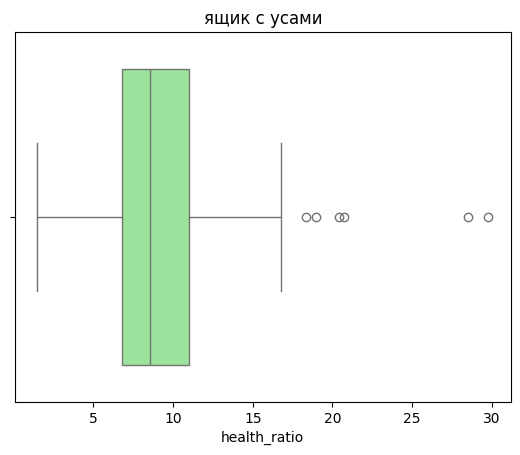

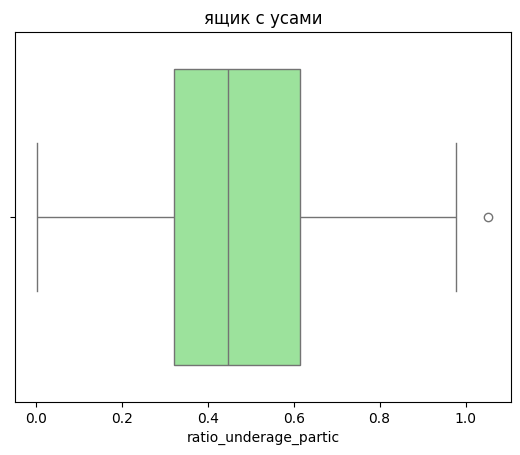

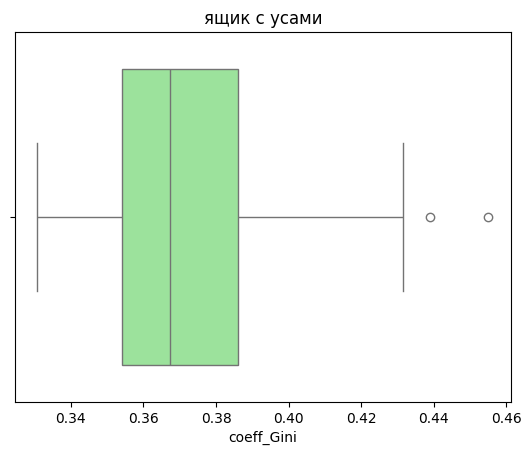

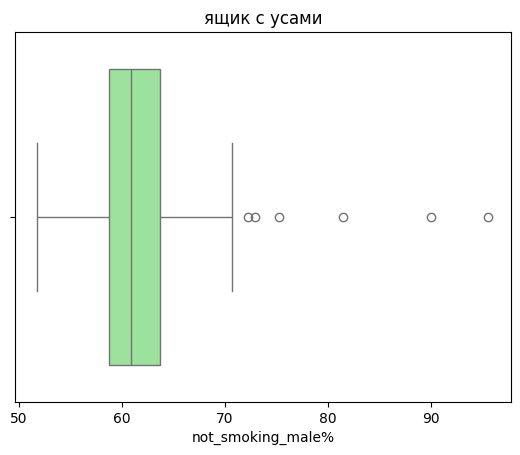

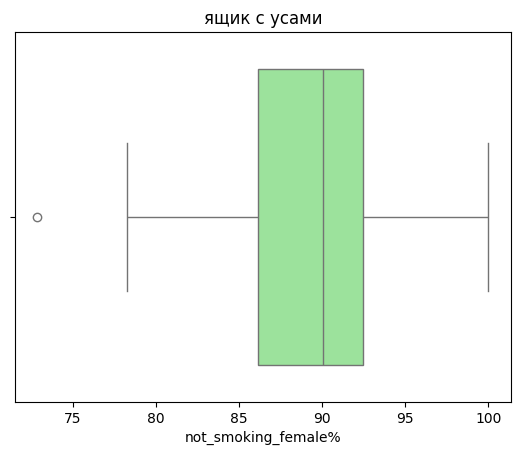

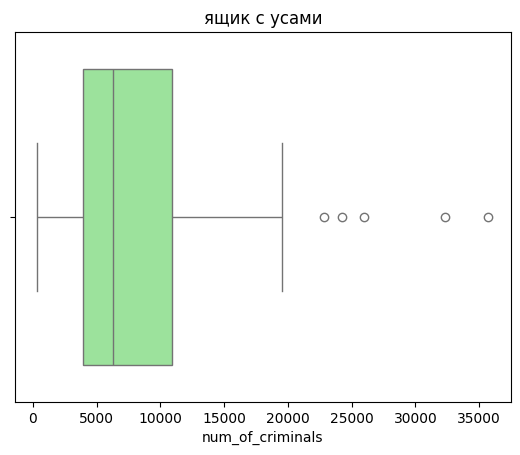

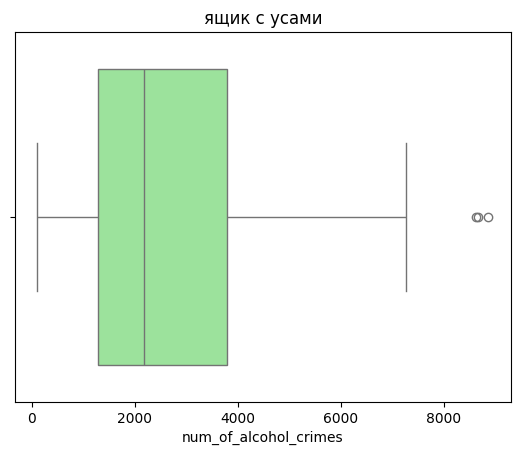

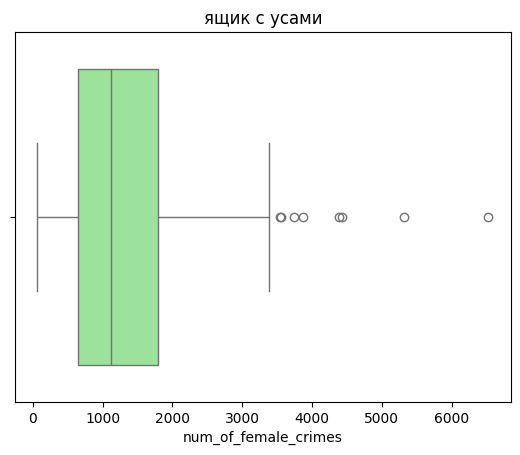

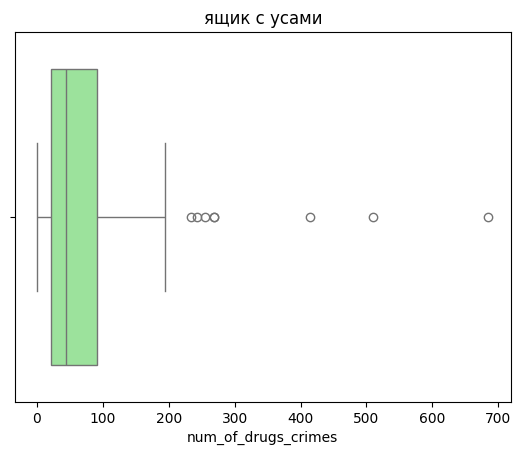

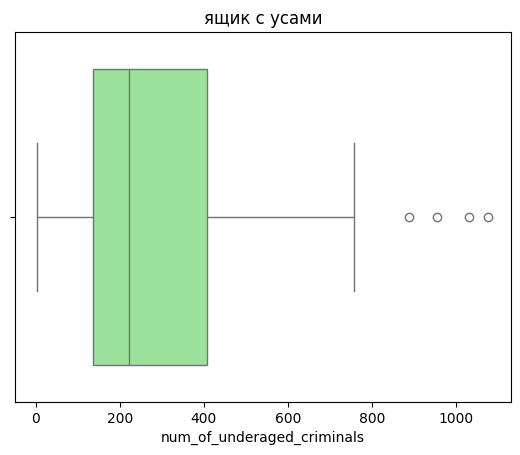

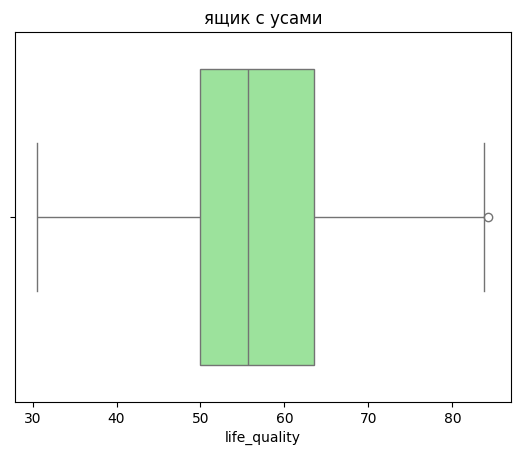

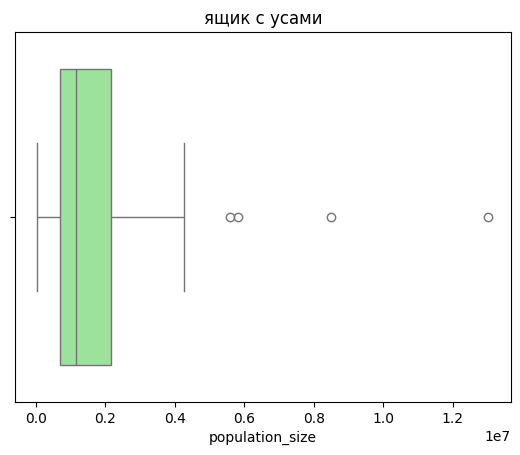

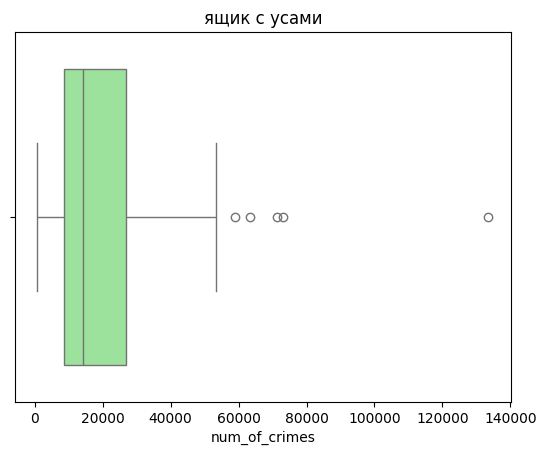

In [175]:
for col in desc.columns:
    sns.boxplot(x=df[col], color='lightgreen')
    plt.title('ящик с усами')
    plt.show()

In [158]:
df[df['health_ratio']>17]

,region,health_ratio,ratio_underage_partic,coeff_Gini,not_smoking_male%,not_smoking_female%,num_of_criminals,num_of_alcohol_crimes,num_of_female_crimes,num_of_drugs_crimes,num_of_underaged_criminals,life_quality,population_size,num_of_crimes
26,Новгородская область,18.350000,0.940383,0.3480,60.308352,87.126608,3581.000000,1387.833333,640.000000,15.500000,237.000000,52.9765,5.823857e+05,10488.0
29,Республика Адыгея (Адыгея),20.750000,0.315967,0.4044,58.769229,93.171855,2005.000000,456.166667,335.000000,9.833333,72.000000,65.1885,4.939040e+05,4188.6
31,Республика Крым,18.983333,0.371817,0.3326,60.864221,90.027395,10648.666667,2274.333333,1676.500000,60.500000,300.000000,58.5315,1.924850e+06,20915.4
36,г. Севастополь,28.483333,0.323783,0.3330,68.353314,83.966983,2317.500000,677.166667,379.666667,28.000000,68.333333,63.4765,5.419620e+05,6014.2
38,Республика Ингушетия,29.783333,0.071067,0.3360,90.048896,100.000000,1055.833333,114.833333,155.166667,21.833333,25.500000,35.0140,5.109997e+05,2077.8
39,Кабардино-Балкарская Республика,20.400000,0.155133,0.3618,72.913324,99.391425,3948.500000,402.166667,620.333333,41.000000,67.500000,53.9150,9.016403e+05,7038.0


In [159]:
df[df['ratio_underage_partic']>1]

,region,health_ratio,ratio_underage_partic,coeff_Gini,not_smoking_male%,not_smoking_female%,num_of_criminals,num_of_alcohol_crimes,num_of_female_crimes,num_of_drugs_crimes,num_of_underaged_criminals,life_quality,population_size,num_of_crimes
65,Республика Тыва,9.816667,1.05305,0.3738,60.497869,92.714942,3896.333333,1799.5,626.333333,11.666667,251.5,30.582,334510.666667,6314.2


In [163]:
df[df['coeff_Gini']>0.432]

,region,health_ratio,ratio_underage_partic,coeff_Gini,not_smoking_male%,not_smoking_female%,num_of_criminals,num_of_alcohol_crimes,num_of_female_crimes,num_of_drugs_crimes,num_of_underaged_criminals,life_quality,population_size,num_of_crimes
20,Ненецкий автономный округ,9.0,0.709033,0.4388,54.794841,83.631040,362.333333,181.833333,68.166667,0.833333,16.666667,45.3935,41686.666667,780.8
61,Ямало-Ненецкий автономный округ,9.2,0.239133,0.4550,64.156761,88.759741,3052.000000,1319.333333,549.500000,45.666667,69.500000,61.9710,511957.333333,6742.8


In [164]:
df[df['not_smoking_male%']>71]

,region,health_ratio,ratio_underage_partic,coeff_Gini,not_smoking_male%,not_smoking_female%,num_of_criminals,num_of_alcohol_crimes,num_of_female_crimes,num_of_drugs_crimes,num_of_underaged_criminals,life_quality,population_size,num_of_crimes
37,Республика Дагестан,10.033333,0.107033,0.3838,81.477731,99.559966,9379.333333,639.333333,1310.666667,19.833333,206.166667,48.678,3.184540e+06,14126.4
38,Республика Ингушетия,29.783333,0.071067,0.3360,90.048896,100.000000,1055.833333,114.833333,155.166667,21.833333,25.500000,35.014,5.109997e+05,2077.8
39,Кабардино-Балкарская Республика,20.400000,0.155133,0.3618,72.913324,99.391425,3948.500000,402.166667,620.333333,41.000000,67.500000,53.915,9.016403e+05,7038.0
40,Карачаево-Черкесская Республика,15.283333,0.241683,0.3308,72.293795,98.397888,2176.666667,404.833333,315.833333,44.333333,59.666667,44.016,4.692612e+05,4543.8
41,Республика Северная Осетия-Алания,16.800000,0.180233,0.3584,75.278331,99.121918,3916.000000,365.000000,573.000000,47.500000,61.000000,51.276,6.865120e+05,8780.2
42,Чеченская Республика,10.366667,0.003583,0.3784,95.568405,99.938180,1998.166667,107.833333,304.666667,3.166667,4.166667,51.358,1.513272e+06,2570.6


In [165]:
df[df['not_smoking_female%']<75]

,region,health_ratio,ratio_underage_partic,coeff_Gini,not_smoking_male%,not_smoking_female%,num_of_criminals,num_of_alcohol_crimes,num_of_female_crimes,num_of_drugs_crimes,num_of_underaged_criminals,life_quality,population_size,num_of_crimes
83,Еврейская автономная область,9.683333,0.968167,0.3364,52.460141,72.858529,1421.5,437.166667,312.666667,3.166667,73.666667,37.5105,150224.833333,2910.0


In [166]:
df[df['num_of_criminals']>20000]

,region,health_ratio,ratio_underage_partic,coeff_Gini,not_smoking_male%,not_smoking_female%,num_of_criminals,num_of_alcohol_crimes,num_of_female_crimes,num_of_drugs_crimes,num_of_underaged_criminals,life_quality,population_size,num_of_crimes
9,Московская область,8.416667,0.204133,0.3702,63.596436,88.108860,35716.000000,6449.166667,6523.000000,510.000000,625.333333,81.5310,8.506201e+06,71209.2
17,г. Москва,6.266667,0.091250,0.4224,65.478016,86.027151,32329.500000,5096.166667,5319.166667,684.833333,407.000000,84.2720,1.303065e+07,133515.8
32,Краснодарский край,12.350000,0.292833,0.4080,69.083643,92.431741,25991.666667,4854.000000,4380.166667,163.666667,730.333333,76.5920,5.814593e+06,73155.8
59,Свердловская область,6.966667,0.588500,0.4010,59.789230,85.673816,22849.333333,8864.000000,3873.000000,194.500000,1077.333333,65.7735,4.265681e+06,49844.6
63,Челябинская область,5.383333,0.683567,0.3496,57.395253,86.876948,24228.500000,8628.666667,4426.000000,268.833333,1031.166667,64.2015,3.429265e+06,58932.2


In [167]:
df[df['num_of_alcohol_crimes']>8000]

,region,health_ratio,ratio_underage_partic,coeff_Gini,not_smoking_male%,not_smoking_female%,num_of_criminals,num_of_alcohol_crimes,num_of_female_crimes,num_of_drugs_crimes,num_of_underaged_criminals,life_quality,population_size,num_of_crimes
44,Республика Башкортостан,8.500000,0.317183,0.3860,62.239265,93.090185,18908.666667,8664.500000,2976.333333,170.500000,589.500000,63.0520,4.088954e+06,51152.0
59,Свердловская область,6.966667,0.588500,0.4010,59.789230,85.673816,22849.333333,8864.000000,3873.000000,194.500000,1077.333333,65.7735,4.265681e+06,49844.6
63,Челябинская область,5.383333,0.683567,0.3496,57.395253,86.876948,24228.500000,8628.666667,4426.000000,268.833333,1031.166667,64.2015,3.429265e+06,58932.2


In [168]:
df[df['num_of_female_crimes']>3500]

,region,health_ratio,ratio_underage_partic,coeff_Gini,not_smoking_male%,not_smoking_female%,num_of_criminals,num_of_alcohol_crimes,num_of_female_crimes,num_of_drugs_crimes,num_of_underaged_criminals,life_quality,population_size,num_of_crimes
9,Московская область,8.416667,0.204133,0.3702,63.596436,88.108860,35716.000000,6449.166667,6523.000000,510.000000,625.333333,81.5310,8.506201e+06,71209.2
17,г. Москва,6.266667,0.091250,0.4224,65.478016,86.027151,32329.500000,5096.166667,5319.166667,684.833333,407.000000,84.2720,1.303065e+07,133515.8
32,Краснодарский край,12.350000,0.292833,0.4080,69.083643,92.431741,25991.666667,4854.000000,4380.166667,163.666667,730.333333,76.5920,5.814593e+06,73155.8
35,Ростовская область,14.433333,0.338650,0.3938,60.078761,90.836676,19508.000000,3824.333333,3740.000000,112.833333,570.500000,69.6710,4.191164e+06,53308.4
59,Свердловская область,6.966667,0.588500,0.4010,59.789230,85.673816,22849.333333,8864.000000,3873.000000,194.500000,1077.333333,65.7735,4.265681e+06,49844.6
63,Челябинская область,5.383333,0.683567,0.3496,57.395253,86.876948,24228.500000,8628.666667,4426.000000,268.833333,1031.166667,64.2015,3.429265e+06,58932.2
68,Красноярский край,7.350000,0.587017,0.3904,59.083046,87.759586,19433.666667,6829.500000,3535.666667,124.333333,757.166667,56.3615,2.857519e+06,46684.4
70,Кемеровская область - Кузбасс,6.816667,0.764067,0.3548,55.556220,86.957957,18621.000000,7272.500000,3549.666667,91.166667,954.166667,52.3685,2.597398e+06,42257.2


In [169]:
df[df['num_of_drugs_crimes']>200]

,region,health_ratio,ratio_underage_partic,coeff_Gini,not_smoking_male%,not_smoking_female%,num_of_criminals,num_of_alcohol_crimes,num_of_female_crimes,num_of_drugs_crimes,num_of_underaged_criminals,life_quality,population_size,num_of_crimes
9,Московская область,8.416667,0.204133,0.3702,63.596436,88.108860,35716.000000,6449.166667,6523.000000,510.000000,625.333333,81.5310,8.506201e+06,71209.2
17,г. Москва,6.266667,0.091250,0.4224,65.478016,86.027151,32329.500000,5096.166667,5319.166667,684.833333,407.000000,84.2720,1.303065e+07,133515.8
28,г. Санкт-Петербург,7.683333,0.228433,0.4042,69.112247,87.829366,18907.333333,2422.166667,3380.166667,413.666667,396.833333,83.7995,5.591176e+06,63364.2
47,Республика Татарстан,13.983333,0.354267,0.3856,63.653196,95.671876,16978.500000,6552.666667,2656.666667,243.000000,577.833333,75.8540,3.998542e+06,52629.0
55,Самарская область,10.100000,0.353017,0.3716,63.170024,93.071952,13763.666667,4222.833333,2466.000000,268.000000,442.833333,67.4155,3.165386e+06,46097.2
56,Саратовская область,8.233333,0.367817,0.3648,59.531795,90.083433,11209.833333,3992.666667,1903.833333,254.833333,354.666667,56.8390,2.432468e+06,28979.6
63,Челябинская область,5.383333,0.683567,0.3496,57.395253,86.876948,24228.500000,8628.666667,4426.000000,268.833333,1031.166667,64.2015,3.429265e+06,58932.2
71,Новосибирская область,4.100000,0.619767,0.3844,59.604970,87.491973,12892.833333,3852.500000,2166.666667,233.000000,711.166667,63.7460,2.798757e+06,42379.6


In [171]:
df[df['num_of_underaged_criminals']>800]

,region,health_ratio,ratio_underage_partic,coeff_Gini,not_smoking_male%,not_smoking_female%,num_of_criminals,num_of_alcohol_crimes,num_of_female_crimes,num_of_drugs_crimes,num_of_underaged_criminals,life_quality,population_size,num_of_crimes
59,Свердловская область,6.966667,0.588500,0.4010,59.789230,85.673816,22849.333333,8864.000000,3873.000000,194.500000,1077.333333,65.7735,4.265681e+06,49844.6
63,Челябинская область,5.383333,0.683567,0.3496,57.395253,86.876948,24228.500000,8628.666667,4426.000000,268.833333,1031.166667,64.2015,3.429265e+06,58932.2
69,Иркутская область,5.816667,0.763783,0.3680,61.665829,85.352392,17008.000000,6559.000000,3310.166667,118.666667,888.500000,51.1080,2.363651e+06,36904.0
70,Кемеровская область - Кузбасс,6.816667,0.764067,0.3548,55.556220,86.957957,18621.000000,7272.500000,3549.666667,91.166667,954.166667,52.3685,2.597398e+06,42257.2


In [172]:
df[df['life_quality']>84]

,region,health_ratio,ratio_underage_partic,coeff_Gini,not_smoking_male%,not_smoking_female%,num_of_criminals,num_of_alcohol_crimes,num_of_female_crimes,num_of_drugs_crimes,num_of_underaged_criminals,life_quality,population_size,num_of_crimes
17,г. Москва,6.266667,0.09125,0.4224,65.478016,86.027151,32329.5,5096.166667,5319.166667,684.833333,407.0,84.272,13030647.0,133515.8


In [176]:
df[df['population_size']>0.5*(10**7)]

,region,health_ratio,ratio_underage_partic,coeff_Gini,not_smoking_male%,not_smoking_female%,num_of_criminals,num_of_alcohol_crimes,num_of_female_crimes,num_of_drugs_crimes,num_of_underaged_criminals,life_quality,population_size,num_of_crimes
9,Московская область,8.416667,0.204133,0.3702,63.596436,88.108860,35716.000000,6449.166667,6523.000000,510.000000,625.333333,81.5310,8506201,71209.2
17,г. Москва,6.266667,0.091250,0.4224,65.478016,86.027151,32329.500000,5096.166667,5319.166667,684.833333,407.000000,84.2720,13030647,133515.8
28,г. Санкт-Петербург,7.683333,0.228433,0.4042,69.112247,87.829366,18907.333333,2422.166667,3380.166667,413.666667,396.833333,83.7995,5591176,63364.2
32,Краснодарский край,12.350000,0.292833,0.4080,69.083643,92.431741,25991.666667,4854.000000,4380.166667,163.666667,730.333333,76.5920,5814592,73155.8


In [177]:
df[df['num_of_crimes']>55000]

,region,health_ratio,ratio_underage_partic,coeff_Gini,not_smoking_male%,not_smoking_female%,num_of_criminals,num_of_alcohol_crimes,num_of_female_crimes,num_of_drugs_crimes,num_of_underaged_criminals,life_quality,population_size,num_of_crimes
9,Московская область,8.416667,0.204133,0.3702,63.596436,88.108860,35716.000000,6449.166667,6523.000000,510.000000,625.333333,81.5310,8506201,71209.2
17,г. Москва,6.266667,0.091250,0.4224,65.478016,86.027151,32329.500000,5096.166667,5319.166667,684.833333,407.000000,84.2720,13030647,133515.8
28,г. Санкт-Петербург,7.683333,0.228433,0.4042,69.112247,87.829366,18907.333333,2422.166667,3380.166667,413.666667,396.833333,83.7995,5591176,63364.2
32,Краснодарский край,12.350000,0.292833,0.4080,69.083643,92.431741,25991.666667,4854.000000,4380.166667,163.666667,730.333333,76.5920,5814592,73155.8
63,Челябинская область,5.383333,0.683567,0.3496,57.395253,86.876948,24228.500000,8628.666667,4426.000000,268.833333,1031.166667,64.2015,3429264,58932.2


In [180]:
df = df.set_index('region')
df.to_csv('csv/preprocessed.csv')

In [184]:
y = df['ratio_underage_partic']
x = df.drop('ratio_underage_partic', axis=1)

In [186]:
x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [197]:
scaler = StandardScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns = x_train.columns, index = x_train.index)
x_test_scaled = pd.DataFrame(scaler.fit_transform(x_test), columns = x_test.columns, index = x_test.index)

In [198]:
x_train_scaled

,health_ratio,coeff_Gini,not_smoking_male%,not_smoking_female%,num_of_criminals,num_of_alcohol_crimes,num_of_female_crimes,num_of_drugs_crimes,num_of_underaged_criminals,life_quality,population_size,num_of_crimes
region,,,,,,,,,,,,
Камчатский край,-0.211502,0.617024,0.180142,-1.887970,-0.791271,-0.870290,-0.788675,-0.526915,-0.819885,-0.205576,-0.730377,-0.756990
Чеченская Республика,0.121626,0.282669,4.436973,1.952737,-0.899576,-1.206351,-0.928525,-0.680619,-1.187732,-0.460377,-0.122629,-0.888223
Чувашская Республика - Чувашия,1.217104,-0.658189,0.258951,1.291488,-0.469173,-0.349584,-0.516171,0.046630,-0.488689,0.540124,-0.285649,-0.439381
Рязанская область,0.246549,-0.246078,0.924062,0.762747,-0.572647,-0.671922,-0.566276,-0.572457,-0.785899,0.531495,-0.328104,-0.601380
Республика Калмыкия,-0.675960,-1.373553,0.642483,1.193068,-0.962177,-1.011067,-1.038678,-0.616576,-1.051788,-0.824505,-0.742682,-0.881657
Кабардино-Балкарская Республика,2.049924,-0.362713,1.374638,1.854067,-0.631630,-1.070200,-0.680746,-0.357555,-0.934504,-0.221854,-0.427094,-0.680796
г. Санкт-Петербург,-0.394082,1.285733,0.860838,-0.232457,1.423481,-0.135797,1.485549,2.824695,0.382282,2.565844,1.907313,1.934499
Московская область,-0.253143,-0.036134,0.115255,-0.182019,3.732730,1.726996,3.952475,3.647299,1.295903,2.354233,3.358384,2.298752
Республика Алтай,-1.207683,0.166034,-0.868705,-1.016782,-0.792118,-0.707155,-0.816148,-0.626538,-0.831213,-1.156497,-0.770917,-0.805538


In [199]:
x_test_scaled

,health_ratio,coeff_Gini,not_smoking_male%,not_smoking_female%,num_of_criminals,num_of_alcohol_crimes,num_of_female_crimes,num_of_drugs_crimes,num_of_underaged_criminals,life_quality,population_size,num_of_crimes
region,,,,,,,,,,,,
Приморский край,-1.596919,0.241816,0.467580,-1.251604,0.727845,0.564976,0.807805,0.071787,1.213535,-0.211448,0.196600,0.586924
Белгородская область,0.052746,0.302868,0.019899,0.737287,-0.513684,-0.580541,-0.570361,-0.632811,-0.754635,0.861894,-0.066719,-0.463053
Красноярский край,-0.637009,0.984622,-0.719703,-0.610576,1.959145,2.323310,1.988108,0.587571,2.337839,-0.032912,1.052575,1.492396
Вологодская область,-0.447327,-0.704498,-0.192837,-0.238822,-0.324501,0.011348,-0.289126,0.592176,0.024645,-0.601721,-0.394457,-0.321332
Смоленская область,-1.073854,0.770938,-0.836600,-0.617425,-0.608246,-0.680262,-0.545137,-0.886098,-0.472497,-0.158361,-0.606121,-0.520777
Сахалинская область,-0.637009,1.971637,-1.698890,-2.325840,-0.799457,-0.711419,-0.839312,-0.197618,-0.657756,-0.249210,-0.963053,-0.831355
Орловская область,-0.435831,0.129886,-0.113905,0.128316,-1.000061,-1.047517,-0.907614,-0.895308,-1.078414,-0.052067,-0.755962,-0.877169
Республика Карелия,-0.665749,-0.511165,1.047902,-1.001819,-0.754069,-0.565767,-0.753483,-0.499259,-0.340776,-1.522614,-0.903505,-0.647161
Ивановская область,0.115974,-0.480639,-0.290197,0.116974,-0.678682,-0.488490,-0.618517,-0.872282,-0.549830,-0.123943,-0.572766,-0.631424


In [201]:
x_train.to_csv('csv/predictors_train.csv')
x_test.to_csv('csv/predictors_test.csv')
x_train_scaled.to_csv('csv/predictors_scaled_train.csv')
x_test_scaled.to_csv('csv/predictors_scaled_test.csv')

y_train.to_csv('csv/target_train.csv')
y_test.to_csv('csv/target_test.csv')